# 자치구별 유동인구, 주차확보율, 민원 점수 분석

이 노트북은 `branch_SG/traffic_analystic` 폴더의 데이터를 사용해 자치구별 유동인구와 주차장확보율의 상관관계를 보고, 주차장확보율 기반 주차 문제 점수와 인구보정 민원 문제 점수를 산출합니다.

- 월별 유동인구 파일의 `month`는 분기 대표월로 간주합니다.
- `1월/2월 -> 1분기`, `5월 -> 2분기`, `8월 -> 3분기`, `11월 -> 4분기`로 변환합니다.
- 분기 총 유동인구수는 대표월 값에 `3`을 곱합니다.
- 점수 산출은 `연도-분기-자치구` 단위로 집계한 뒤 수행합니다.
- 민원은 인구 1만 명당 민원으로 보정한 뒤, 많을수록 높은 문제 점수로 환산합니다.
- 문제 점수는 5~95 분위수 기반 min-max를 적용한 뒤 10~90 범위로 압축합니다.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import font_manager

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None

# Windows 한글 폰트 파일을 직접 등록합니다. 폰트명 탐색보다 안정적입니다.
font_path = Path('C:/Windows/Fonts/malgun.ttf')
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(font_path)).get_name()
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR_CANDIDATES = [
    Path('traffic_analystic_data'),
    Path('branch_SG/traffic_analystic'),
    Path('branch_SG/traffic_analystic/traffic_analystic_data'),
    Path('.'),
    Path.cwd(),
    Path.cwd() / 'traffic_analystic_data',
    Path.cwd() / 'branch_SG' / 'traffic_analystic',
    Path.cwd() / 'branch_SG' / 'traffic_analystic' / 'traffic_analystic_data',
]
for parent in Path.cwd().resolve().parents:
    DATA_DIR_CANDIDATES.extend([
        parent / 'branch_SG' / 'traffic_analystic',
        parent / 'branch_SG' / 'traffic_analystic' / 'traffic_analystic_data',
    ])
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if (p / 'monthly_scores_문헌기반_서울_202605071520.csv').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('traffic_analystic CSV 파일을 찾지 못했습니다. repo root 또는 branch_SG/traffic_analystic에서 실행해 주세요.')
DATA_DIR = DATA_DIR.resolve()
OUT_DIR = (DATA_DIR.parent if DATA_DIR.name == 'traffic_analystic_data' else DATA_DIR) / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

MONTHLY_PATH = DATA_DIR / 'monthly_scores_문헌기반_서울_202605071520.csv'
BUS_PATH = DATA_DIR / 'bus_gu_wide_202605071519.csv'
SUBWAY_PATH = DATA_DIR / 'subway_gu_wide_202605071519.csv'
GARBAGE_PATH = DATA_DIR / 'Garbage_collection_status.csv'
PARKING_PATH = DATA_DIR / '주차장+확보율_2022_2024.csv'
if not PARKING_PATH.exists():
    PARKING_PATH = next(DATA_DIR.glob('주차장*확보율*.csv'), None)
COMPLAINT_PATH = next(DATA_DIR.glob('*민원건수*.xlsx'), None)

print('DATA_DIR =', DATA_DIR)
print('PARKING_PATH =', PARKING_PATH)
print('COMPLAINT_PATH =', COMPLAINT_PATH)

DATA_DIR = C:\8ssible-Healing-Seoul-Analysis\branch_SG\traffic_analystic\traffic_analystic_data
PARKING_PATH = C:\8ssible-Healing-Seoul-Analysis\branch_SG\traffic_analystic\traffic_analystic_data\주차장+확보율_2022_2024.csv
COMPLAINT_PATH = C:\8ssible-Healing-Seoul-Analysis\branch_SG\traffic_analystic\traffic_analystic_data\자치구별 지표별 연도별 민원건수 현황.xlsx


In [2]:
def read_csv_smart(path, **kwargs):
    encodings = ['utf-8-sig', 'utf-8', 'cp949', 'euc-kr']
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except UnicodeDecodeError as exc:
            last_error = exc
    raise last_error

def find_col(df, include=None, exclude=None, exact=None, required=False, label='컬럼'):
    include = include or []
    exclude = exclude or []
    exact = exact or set()
    for col in df.columns:
        if str(col).strip() in exact:
            return col
    for col in df.columns:
        name = str(col).strip().lower()
        if all(k.lower() in name for k in include) and not any(k.lower() in name for k in exclude):
            return col
    if required:
        raise KeyError(f'{label}을 찾지 못했습니다. include={include}, exact={exact}')
    return None

def find_cols(df, any_keywords, all_keywords=None, exclude=None):
    all_keywords = all_keywords or []
    exclude = exclude or []
    result = []
    for col in df.columns:
        name = str(col).strip().lower()
        if any(k.lower() in name for k in any_keywords) and all(k.lower() in name for k in all_keywords) and not any(k.lower() in name for k in exclude):
            result.append(col)
    return result

def quantile_scaled_100(series, higher_is_worse=True, lower_q=0.05, upper_q=0.95, out_min=10, out_max=90):
    s = pd.to_numeric(series, errors='coerce')
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        midpoint = (out_min + out_max) / 2
        return pd.Series(np.where(s.notna(), midpoint, np.nan), index=s.index)
    scaled = (s - lo) / (hi - lo)
    score = scaled * (out_max - out_min) + out_min
    score = score.clip(out_min, out_max)
    return score if higher_is_worse else out_max + out_min - score

def load_parking_csv(path):
    if path is None:
        return pd.DataFrame(columns=['year', 'gu_name', 'registered_cars', 'parking_spaces', 'parking_supply_rate'])
    raw = read_csv_smart(path, header=None)
    year_header = raw.iloc[0].astype(str).tolist()
    metric_header = raw.iloc[1].astype(str).tolist()
    body = raw.iloc[2:].copy()
    gu_col = body.columns[1]
    body = body[body[gu_col].ne('소계')].copy()

    rows = []
    for _, row in body.iterrows():
        gu_name = row[gu_col]
        by_year = {}
        for idx in range(2, raw.shape[1]):
            year_match = re.search(r'20\d{2}', str(year_header[idx]))
            if not year_match:
                continue
            year = int(year_match.group())
            metric = str(metric_header[idx])
            target = None
            if '자동차등록대수' in metric:
                target = 'registered_cars'
            elif '주차면수' in metric:
                target = 'parking_spaces'
            elif '주차장확보율' in metric:
                target = 'parking_supply_rate'
            if target is None:
                continue
            by_year.setdefault(year, {'year': year, 'gu_name': gu_name})[target] = row[idx]
        rows.extend(by_year.values())

    df = pd.DataFrame(rows)
    keep = ['year', 'gu_name', 'registered_cars', 'parking_spaces', 'parking_supply_rate']
    for col in keep[2:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df[keep]

def load_complaint_excel(path):
    if path is None:
        return pd.DataFrame(columns=['year', 'gu_name', 'traffic_complaints', 'safety_complaints', 'environment_complaints'])
    df = pd.read_excel(path)
    rename = {}
    for col in df.columns:
        name = str(col).strip()
        if name == '자치구명':
            rename[col] = 'gu_name'
        elif name == '연도':
            rename[col] = 'year'
        elif '교통' in name and '민원' in name:
            rename[col] = 'traffic_complaints'
        elif '안전' in name and '민원' in name:
            rename[col] = 'safety_complaints'
        elif '환경' in name and '민원' in name:
            rename[col] = 'environment_complaints'
    df = df.rename(columns=rename)
    complaint_value_cols = [c for c in ['traffic_complaints', 'safety_complaints', 'environment_complaints'] if c in df.columns]
    for col in ['year'] + complaint_value_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['year'] = df['year'].astype('Int64')
    keep = ['year', 'gu_name'] + complaint_value_cols
    return df[keep]

def show_shape(name, df):
    print(f'{name}: {df.shape[0]:,}행 x {df.shape[1]:,}열')

## 1. 데이터 불러오기

In [3]:
monthly_raw = read_csv_smart(MONTHLY_PATH)
bus_raw = read_csv_smart(BUS_PATH)
subway_raw = read_csv_smart(SUBWAY_PATH)
garbage_raw = read_csv_smart(GARBAGE_PATH)
parking_raw = load_parking_csv(PARKING_PATH)
complaint_raw = load_complaint_excel(COMPLAINT_PATH)

for name, df in [('monthly', monthly_raw), ('bus', bus_raw), ('subway', subway_raw), ('garbage', garbage_raw), ('parking', parking_raw), ('complaint', complaint_raw)]:
    show_shape(name, df)
    display(df.head(3))

monthly: 8,350행 x 15열


,연도,월,자치구코드,자치구명,총이동인구수,평균이동시간,총이동시간,유입인구_norm,평균이동시간_norm,총이동시간_norm,출퇴근스트레스점수,가중치_유입인구,가중치_평균이동시간,가중치_총이동시간,원본파일
0,2022,1,11240,송파구,563446.22,44.981302,2.534454e+07,1.000000,0.015655,1.000000,65.547931,0.45,0.35,0.2,NaN
1,2022,1,11230,강남구,556713.94,44.413550,2.472564e+07,0.988052,0.013855,0.975580,64.458850,0.45,0.35,0.2,NaN
2,2022,1,11160,강서구,394817.34,42.776841,1.688904e+07,0.700717,0.008667,0.666366,45.162926,0.45,0.35,0.2,NaN


bus: 25행 x 74열


,gu_code,gu_name,202201_geton,202201_getoff,202202_geton,202202_getoff,202203_geton,202203_getoff,202204_geton,202204_getoff,...,202408_geton,202408_getoff,202409_geton,202409_getoff,202410_geton,202410_getoff,202411_geton,202411_getoff,202412_geton,202412_getoff
0,11110,종로구,3918759,3744989,3399703,3260335,4117154,3909683,4691873,4452522,...,5115687,4893355,5159753,4912638,5694111,5434703,5518258,5285962,5278899,5076381
1,11140,중구,2807933,2678519,2411271,2295169,2855342,2712931,3343044,3146600,...,3908647,3761632,3844092,3687658,4201329,4031167,4016436,3882968,3925222,3809589
2,11170,용산구,3055904,2967901,2631293,2552445,3131183,3022810,3607663,3480050,...,4076271,3950741,4121405,3977476,4506669,4351994,4308499,4166236,4171545,4040492


subway: 25행 x 76열


...

,자치구,2022_행정구역(A)_면적 (km²),2022_행정구역(A)_인구 (명),2022_청소구역(B)_면적 (km²),2022_청소구역(B)_인구 (명),2022_처리방법 (톤/년)_소계,2022_처리방법 (톤/년)_매립,2022_처리방법 (톤/년)_소각,2023_행정구역(A)_면적 (km²),2023_행정구역(A)_인구 (명),...,2023_처리방법 (톤/년)_소계,2023_처리방법 (톤/년)_매립,2023_처리방법 (톤/년)_소각,2024_행정구역(A)_면적 (km²),2024_행정구역(A)_인구 (명),2024_청소구역(B)_면적 (km²),2024_청소구역(B)_인구 (명),2024_처리방법 (톤/년)_소계,2024_처리방법 (톤/년)_매립,2024_처리방법 (톤/년)_소각
0,소계,605.21,9667669,605.21,9667669,1.590432e+07,431348.39853,971704.040044,605.20,9638799,...,1.374121e+07,343719.49013,1.032403e+06,605.25,9597372,605.25,9597372,1.409548e+07,287640.66289,1049468.662
1,종로구,23.91,152211,23.91,152211,3.880167e+05,7125.50000,41873.419394,23.91,150453,...,3.262330e+05,6172.50000,4.053225e+04,23.91,149608,23.91,149608,2.805180e+05,4060.71000,40085.742
2,중구,9.96,130785,9.96,130785,4.418359e+05,8793.06000,45657.150932,9.96,131793,...,3.491385e+05,6945.73000,4.704887e+04,9.96,131214,9.96,131214,4.632012e+05,4812.94800,43340.320


parking: 75행 x 5열


,year,gu_name,registered_cars,parking_spaces,parking_supply_rate
0,2022,종로구,50336,92062,182.9
1,2023,종로구,50767,91438,180.1
2,2024,종로구,50098,91109,181.9


complaint: 75행 x 5열


,year,gu_name,traffic_complaints,safety_complaints,environment_complaints
0,2022,강서구,47054,128,521
1,2022,양천구,19567,79,186
2,2022,구로구,7625,88,369


## 2. 월 데이터를 분기 데이터로 변환

월별 유동인구 파일의 월은 분기 대표월이므로 `총이동인구수 * 3`으로 분기 총 유동인구수를 계산합니다.

In [4]:
monthly = monthly_raw.copy()

year_col = find_col(monthly, exact={'연도', 'year'}, include=['연도'], required=True, label='연도')
month_col = find_col(monthly, exact={'월', 'month'}, include=['월'], required=True, label='월')
gu_code_col = find_col(monthly, include=['자치구', '코드']) or find_col(monthly, include=['gu', 'code'])
gu_name_col = find_col(monthly, include=['자치구', '명']) or find_col(monthly, exact={'gu_name', '자치구명'}, required=True, label='자치구명')
flow_col = find_col(monthly, include=['총', '이동', '인구'], required=True, label='총이동인구수')

rename_map = {year_col: 'year', month_col: 'month', gu_name_col: 'gu_name', flow_col: 'monthly_flow_population'}
if gu_code_col:
    rename_map[gu_code_col] = 'gu_code'
monthly = monthly.rename(columns=rename_map)

monthly['year'] = pd.to_numeric(monthly['year'], errors='coerce').astype('Int64')
monthly['month'] = pd.to_numeric(monthly['month'], errors='coerce').astype('Int64')
month_to_quarter = {1: 1, 2: 1, 5: 2, 8: 3, 11: 4}
monthly['quarter'] = monthly['month'].map(month_to_quarter).astype('Int64')
monthly['quarter_label'] = monthly['year'].astype(str) + 'Q' + monthly['quarter'].astype(str)
monthly['quarter_flow_population'] = pd.to_numeric(monthly['monthly_flow_population'], errors='coerce') * 3

unknown_months = sorted(monthly.loc[monthly['quarter'].isna(), 'month'].dropna().unique().tolist())
if unknown_months:
    warnings.warn(f'분기 매핑에 없는 month가 있습니다: {unknown_months}')

quarterly_flow = monthly.groupby(['year', 'quarter', 'quarter_label', 'gu_name'], as_index=False).agg(
    quarter_flow_population=('quarter_flow_population', 'sum'),
    monthly_flow_population=('monthly_flow_population', 'sum'),
)
display(quarterly_flow.head())
quarterly_flow.to_csv(OUT_DIR / 'quarterly_flow_population.csv', index=False, encoding='utf-8-sig')

,year,quarter,quarter_label,gu_name,quarter_flow_population,monthly_flow_population
0,2022,1,2022Q1,강남구,1670141.82,556713.94
1,2022,1,2022Q1,강동구,1065545.49,355181.83
2,2022,1,2022Q1,강북구,665644.80,221881.60
3,2022,1,2022Q1,강서구,1184452.02,394817.34
4,2022,1,2022Q1,관악구,953105.49,317701.83


## 3. 버스/지하철 승하차량 보조 집계

In [5]:
def transit_wide_to_long(df, mode):
    id_cols = [c for c in ['gu_code', 'gu_name'] if c in df.columns]
    if not id_cols:
        first_two = list(df.columns[:2])
        df = df.rename(columns={first_two[0]: 'gu_code', first_two[1]: 'gu_name'})
        id_cols = ['gu_code', 'gu_name']
    value_cols = [c for c in df.columns if re.match(r'^\d{6}_(geton|getoff)$', str(c))]
    long = df.melt(id_vars=id_cols, value_vars=value_cols, var_name='ym_type', value_name='count')
    long[['ym', 'type']] = long['ym_type'].str.extract(r'^(\d{6})_(geton|getoff)$')
    long['year'] = long['ym'].str[:4].astype(int)
    long['month'] = long['ym'].str[4:6].astype(int)
    long['quarter'] = ((long['month'] - 1) // 3 + 1).astype(int)
    long['count'] = pd.to_numeric(long['count'], errors='coerce')
    long['mode'] = mode
    return long

transit_long = pd.concat([
    transit_wide_to_long(bus_raw, 'bus'),
    transit_wide_to_long(subway_raw, 'subway'),
], ignore_index=True)

transit_quarterly_total = transit_long.groupby(['year', 'quarter', 'gu_name'], as_index=False)['count'].sum()
transit_quarterly_total = transit_quarterly_total.rename(columns={'count': 'transit_geton_getoff_total'})
display(transit_quarterly_total.head())
transit_quarterly_total.to_csv(OUT_DIR / 'quarterly_bus_subway_geton_getoff.csv', index=False, encoding='utf-8-sig')

,year,quarter,gu_name,transit_geton_getoff_total
0,2022,1,강남구,89654052
1,2022,1,강동구,32240045
2,2022,1,강북구,29444425
3,2022,1,강서구,38303531
4,2022,1,관악구,47463195


## 4. 인구보정용 자치구 인구 테이블 생성

In [6]:
garbage = garbage_raw.copy()
garbage_gu_col = find_col(garbage, exact={'자치구'}, required=True, label='자치구')
population_cols = [c for c in garbage.columns if re.search(r'20\d{2}.*인구', str(c)) and '행정구역' in str(c)]
if not population_cols:
    population_cols = [c for c in garbage.columns if re.search(r'20\d{2}.*인구', str(c))]

population_long = garbage[[garbage_gu_col] + population_cols].rename(columns={garbage_gu_col: 'gu_name'})
population_long = population_long[population_long['gu_name'] != '소계']
population_long = population_long.melt(id_vars='gu_name', var_name='source_col', value_name='resident_population')
population_long['year'] = population_long['source_col'].str.extract(r'(20\d{2})').astype(int)
population_long['resident_population'] = pd.to_numeric(population_long['resident_population'], errors='coerce')
population_long = population_long[['year', 'gu_name', 'resident_population']]
display(population_long.head())
population_long.to_csv(OUT_DIR / 'population_by_gu_year.csv', index=False, encoding='utf-8-sig')

,year,gu_name,resident_population
0,2022,종로구,152211
1,2022,중구,130785
2,2022,용산구,233284
3,2022,성동구,288234
4,2022,광진구,351252


## 5. 유동인구와 주차장확보율 상관분석

,gu_name,quarter_flow_population,registered_cars,parking_spaces,parking_supply_rate,resident_population
0,강남구,1.262871e+09,252349.000000,423742.333333,167.933333,549200.000000
17,송파구,1.040518e+09,245779.333333,335052.333333,136.333333,660283.000000
14,서초구,8.407556e+08,177082.333333,312248.333333,176.333333,411201.666667
3,강서구,7.100340e+08,205692.333333,320241.000000,155.700000,568552.666667
19,영등포구,7.039031e+08,144407.666667,203915.333333,141.200000,397686.000000
1,강동구,6.969335e+08,156063.000000,211980.666667,135.900000,469609.666667
12,마포구,6.400219e+08,121960.000000,197135.333333,161.633333,374497.333333
8,노원구,6.354015e+08,152180.666667,179028.000000,117.633333,502497.000000
4,관악구,5.705723e+08,117887.666667,152275.000000,129.166667,498243.000000
16,성북구,5.478525e+08,122300.333333,156566.000000,128.033333,438396.333333


Pearson 상관계수: 0.242 (p-value=0.2445)
Spearman 순위상관계수: 0.308 (p-value=0.1336)


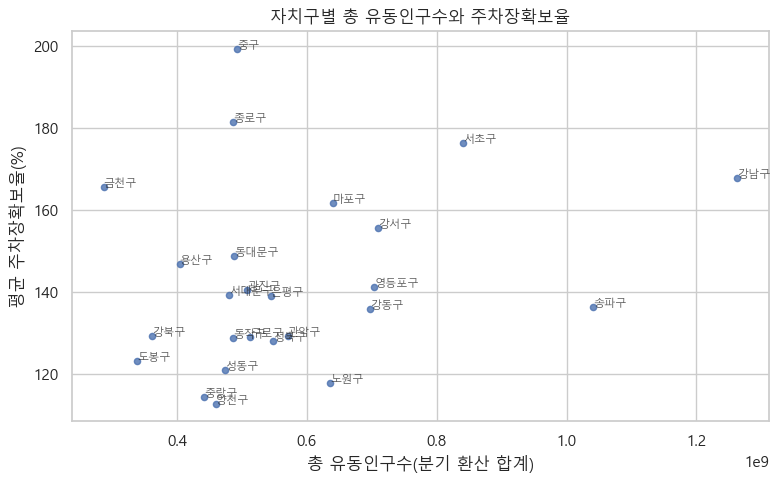

In [7]:
analysis = quarterly_flow.merge(population_long, on=['year', 'gu_name'], how='left')
parking_merge_keys = ['gu_name']
if 'year' in parking_raw.columns:
    parking_raw['year'] = pd.to_numeric(parking_raw['year'], errors='coerce').astype('Int64')
    analysis['year'] = pd.to_numeric(analysis['year'], errors='coerce').astype('Int64')
    parking_merge_keys = ['year', 'gu_name']
analysis = analysis.merge(parking_raw, on=parking_merge_keys, how='left')
analysis = analysis.merge(complaint_raw, on=['year', 'gu_name'], how='left')

gu_corr_base = analysis.groupby('gu_name', as_index=False).agg(
    quarter_flow_population=('quarter_flow_population', 'sum'),
    registered_cars=('registered_cars', 'mean'),
    parking_spaces=('parking_spaces', 'mean'),
    parking_supply_rate=('parking_supply_rate', 'mean'),
    resident_population=('resident_population', 'mean'),
)
display(gu_corr_base.sort_values('quarter_flow_population', ascending=False).head(10))

corr_df = gu_corr_base[['quarter_flow_population', 'parking_supply_rate']].dropna()
if len(corr_df) >= 3:
    pearson_corr, pearson_p = stats.pearsonr(corr_df['quarter_flow_population'], corr_df['parking_supply_rate'])
    spearman_corr, spearman_p = stats.spearmanr(corr_df['quarter_flow_population'], corr_df['parking_supply_rate'])
    print(f'Pearson 상관계수: {pearson_corr:.3f} (p-value={pearson_p:.4f})')
    print(f'Spearman 순위상관계수: {spearman_corr:.3f} (p-value={spearman_p:.4f})')

    ax = gu_corr_base.plot.scatter(x='quarter_flow_population', y='parking_supply_rate', figsize=(8, 5), alpha=0.8)
    for _, row in gu_corr_base.dropna(subset=['quarter_flow_population', 'parking_supply_rate']).iterrows():
        ax.annotate(row['gu_name'], (row['quarter_flow_population'], row['parking_supply_rate']), fontsize=8, alpha=0.75)
    ax.set_title('자치구별 총 유동인구수와 주차장확보율')
    ax.set_xlabel('총 유동인구수(분기 환산 합계)')
    ax.set_ylabel('평균 주차장확보율(%)')
    plt.tight_layout()
    plt.show()
else:
    print('상관분석을 수행할 만큼 주차장확보율 데이터가 충분하지 않습니다.')

gu_corr_base.to_csv(OUT_DIR / 'gu_flow_parking_supply_rate_correlation_base.csv', index=False, encoding='utf-8-sig')

## 6. 민원 점수와 주차장 점수 산출

- 주차장 점수: 주차장확보율이 낮을수록 높은 문제 점수로 환산
- 민원 점수: 인구 1만 명당 교통 민원으로 보정 후, 민원이 많을수록 높은 문제 점수로 환산
- 정규화 방식: 5~95 분위수 기반 min-max 후 10~90 범위로 압축
- 민원 점수에는 `민원건수 (교통)`만 사용합니다.

In [8]:
score_df = analysis.copy()
# 주차 문제 점수는 단순 주차면수가 아니라 등록차량 대비 주차장확보율을 사용합니다.
score_df['parking_score_100'] = quantile_scaled_100(score_df['parking_supply_rate'], higher_is_worse=False)

# 민원 점수는 교통 민원 건수만 사용합니다.
if 'traffic_complaints' in score_df.columns and score_df['traffic_complaints'].notna().any():
    score_df['complaints'] = score_df['traffic_complaints']
    score_df['complaints_per_10k'] = score_df['complaints'] / score_df['resident_population'] * 10_000
    score_df['complaint_score_100'] = quantile_scaled_100(score_df['complaints_per_10k'], higher_is_worse=True)
else:
    score_df['complaints'] = np.nan
    score_df['complaints_per_10k'] = np.nan
    score_df['complaint_score_100'] = np.nan

result_cols = [
    'year', 'quarter', 'quarter_label', 'gu_name',
    'quarter_flow_population', 'resident_population',
    'registered_cars', 'parking_spaces', 'parking_supply_rate', 'parking_score_100',
    'traffic_complaints', 'safety_complaints', 'environment_complaints',
    'complaints', 'complaints_per_10k', 'complaint_score_100',
]
result = score_df[[c for c in result_cols if c in score_df.columns]].sort_values(['year', 'quarter', 'gu_name'])
display(result.head(20))
result.to_csv(OUT_DIR / 'quarterly_parking_complaint_scores.csv', index=False, encoding='utf-8-sig')

,year,quarter,quarter_label,gu_name,quarter_flow_population,resident_population,registered_cars,parking_spaces,parking_supply_rate,parking_score_100,traffic_complaints,safety_complaints,environment_complaints,complaints,complaints_per_10k,complaint_score_100
0,2022,1,2022Q1,강남구,1670141.82,534103,248320,413898,166.7,28.947368,65168,164,1060,65168,1220.139187,61.407410
1,2022,1,2022Q1,강동구,1065545.49,464037,153186,209959,137.1,63.567251,16929,89,430,16929,364.820047,17.861293
2,2022,1,2022Q1,강북구,665644.80,297702,75180,96636,128.5,73.625731,4950,36,847,4950,166.273656,10.000000
3,2022,1,2022Q1,강서구,1184452.02,574638,207536,315812,152.2,45.906433,47054,128,521,47054,818.845952,40.976718
4,2022,1,2022Q1,관악구,953105.49,501226,118615,153960,129.8,72.105263,24025,62,311,24025,479.324696,23.690969
5,2022,1,2022Q1,광진구,879932.88,351252,98535,134389,136.4,64.385965,24489,80,339,24489,697.191760,34.783044
6,2022,1,2022Q1,구로구,795304.11,418418,148659,191823,129.0,73.040936,7625,88,369,7625,182.234034,10.000000
7,2022,1,2022Q1,금천구,420199.20,242818,91676,139148,151.8,46.374269,8752,33,334,8752,360.434564,17.638019
8,2022,1,2022Q1,노원구,1145594.52,508014,152529,178194,116.8,87.309942,9409,48,135,9409,185.211431,10.000000
9,2022,1,2022Q1,도봉구,636924.33,313989,95690,110933,115.9,88.362573,6835,63,120,6835,217.682785,10.370222


## 7. 자치구별 평균 점수 요약

,gu_name,quarter_flow_population,registered_cars,parking_spaces,parking_supply_rate,parking_score_100,complaints_per_10k,complaint_score_100
24,중랑구,4.414838e+08,116219.333333,132870.000000,114.333333,89.961014,258.581679,12.452472
18,양천구,4.604474e+08,151162.000000,170464.333333,112.733333,88.752437,455.354950,22.470618
8,노원구,6.354015e+08,152180.666667,179028.000000,117.633333,86.335283,205.350969,10.170038
15,성동구,4.734285e+08,104337.666667,126300.666667,121.033333,82.358674,392.696984,19.280568
9,도봉구,3.381902e+08,94952.666667,116940.666667,123.166667,79.863548,243.267316,11.672785
16,성북구,5.478525e+08,122300.333333,156566.000000,128.033333,74.171540,262.878076,12.671211
11,동작구,4.859982e+08,106240.666667,136919.000000,128.866667,73.196881,317.773996,15.466079
6,구로구,5.128326e+08,147422.333333,190275.333333,129.066667,72.962963,247.360050,12.359338
2,강북구,3.615143e+08,74485.666667,96199.000000,129.133333,72.884990,258.622278,13.203581
4,관악구,5.705723e+08,117887.666667,152275.000000,129.166667,72.846004,520.045300,25.764141


,gu_name,quarter_flow_population,registered_cars,parking_spaces,parking_supply_rate,parking_score_100,complaints_per_10k,complaint_score_100
23,중구,4.925262e+08,55324.666667,110009.333333,199.366667,10.000000,1837.376371,88.525192
20,용산구,4.038472e+08,74460.666667,109378.333333,146.833333,52.183236,1796.697498,84.863859
14,서초구,8.407556e+08,177082.333333,312248.333333,176.333333,17.680312,1412.337666,71.192644
12,마포구,6.400219e+08,121960.000000,197135.333333,161.633333,34.873294,1351.843218,68.112743
22,종로구,4.864086e+08,50400.333333,91536.333333,181.633333,11.481481,1164.772126,58.588555
0,강남구,1.262871e+09,252349.000000,423742.333333,167.933333,27.504873,1150.621210,57.868102
3,강서구,7.100340e+08,205692.333333,320241.000000,155.700000,41.812865,1147.862954,57.727673
19,영등포구,7.039031e+08,144407.666667,203915.333333,141.200000,58.771930,826.690753,41.376113
5,광진구,5.076846e+08,97499.000000,136804.333333,140.366667,59.746589,585.283361,29.085550
10,동대문구,4.878214e+08,101539.666667,151174.666667,148.900000,49.766082,568.368574,28.224382


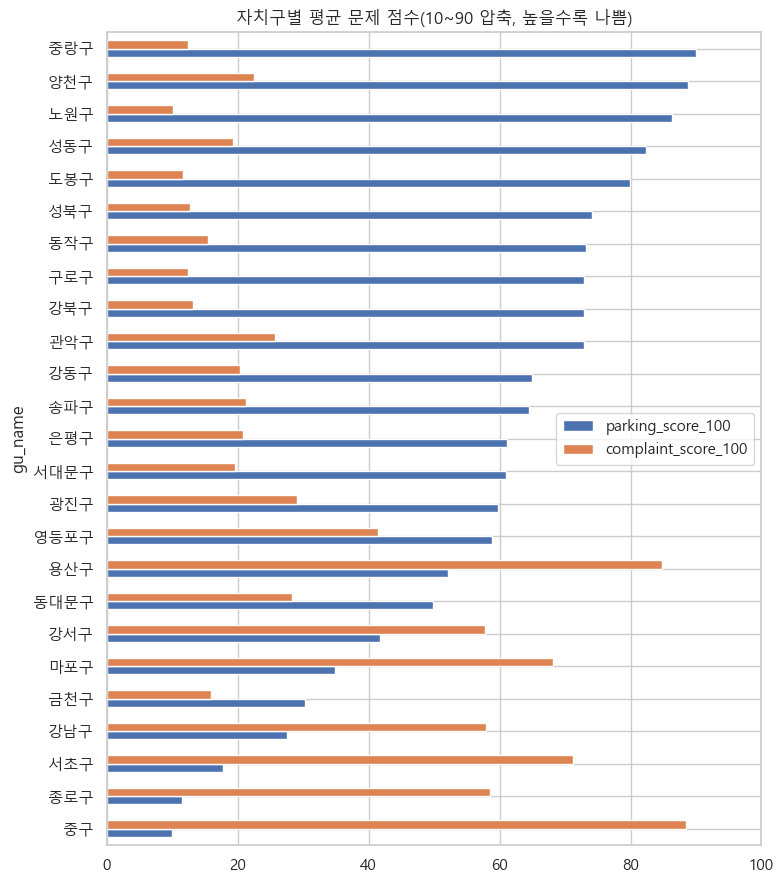

저장 완료: C:\8ssible-Healing-Seoul-Analysis\branch_SG\traffic_analystic\outputs


In [9]:
gu_score_summary = result.groupby('gu_name', as_index=False).agg(
    quarter_flow_population=('quarter_flow_population', 'sum'),
    registered_cars=('registered_cars', 'mean'),
    parking_spaces=('parking_spaces', 'mean'),
    parking_supply_rate=('parking_supply_rate', 'mean'),
    parking_score_100=('parking_score_100', 'mean'),
    complaints_per_10k=('complaints_per_10k', 'mean'),
    complaint_score_100=('complaint_score_100', 'mean'),
)

display(gu_score_summary.sort_values('parking_score_100', ascending=False).head(10))
display(gu_score_summary.sort_values('complaint_score_100', ascending=False).head(10))

plot_cols = ['parking_score_100', 'complaint_score_100']
available_plot_cols = [c for c in plot_cols if gu_score_summary[c].notna().any()]
if available_plot_cols:
    ax = gu_score_summary.set_index('gu_name')[available_plot_cols].sort_values(available_plot_cols[0]).plot.barh(figsize=(8, 9))
    ax.set_xlim(0, 100)
    ax.set_title('자치구별 평균 문제 점수(10~90 압축, 높을수록 나쁨)')
    plt.tight_layout()
    plt.show()

gu_score_summary.to_csv(OUT_DIR / 'gu_parking_complaint_score_summary.csv', index=False, encoding='utf-8-sig')
print('저장 완료:', OUT_DIR)

## 8. 주차 문제 점수와 민원 문제 점수 상관분석

parking_score_100과 complaint_score_100는 모두 높을수록 문제가 큰 점수이며, 5~95 분위수 기반 min-max 후 10~90 범위로 압축한 값입니다. 분기 단위 결과와 자치구 평균 요약 기준의 Pearson/Spearman 상관계수를 함께 확인합니다.

,analysis_unit,n,pearson_corr,pearson_p_value,spearman_corr,spearman_p_value
0,분기 단위,300,-0.749551,2.476544e-55,-0.738362,6.504820e-53
1,자치구 평균,25,-0.782557,3.792278e-06,-0.801538,1.466876e-06


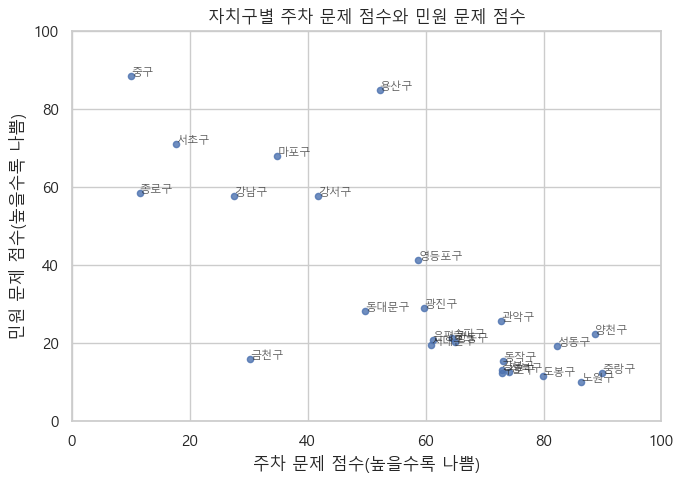

In [10]:
score_corr_cols = ['parking_score_100', 'complaint_score_100']

quarter_score_corr = result[score_corr_cols].dropna()
gu_score_corr = gu_score_summary[score_corr_cols].dropna()

corr_rows = []
for label, df_corr in [('분기 단위', quarter_score_corr), ('자치구 평균', gu_score_corr)]:
    if len(df_corr) >= 3:
        pearson_corr, pearson_p = stats.pearsonr(df_corr['parking_score_100'], df_corr['complaint_score_100'])
        spearman_corr, spearman_p = stats.spearmanr(df_corr['parking_score_100'], df_corr['complaint_score_100'])
        corr_rows.append({
            'analysis_unit': label,
            'n': len(df_corr),
            'pearson_corr': pearson_corr,
            'pearson_p_value': pearson_p,
            'spearman_corr': spearman_corr,
            'spearman_p_value': spearman_p,
        })
    else:
        corr_rows.append({
            'analysis_unit': label,
            'n': len(df_corr),
            'pearson_corr': np.nan,
            'pearson_p_value': np.nan,
            'spearman_corr': np.nan,
            'spearman_p_value': np.nan,
        })

score_corr_summary = pd.DataFrame(corr_rows)
display(score_corr_summary)

if len(gu_score_corr) >= 2:
    ax = gu_score_summary.plot.scatter(
        x='parking_score_100',
        y='complaint_score_100',
        figsize=(7, 5),
        alpha=0.8,
    )
    for _, row in gu_score_summary.dropna(subset=score_corr_cols).iterrows():
        ax.annotate(row['gu_name'], (row['parking_score_100'], row['complaint_score_100']), fontsize=8, alpha=0.75)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel('주차 문제 점수(높을수록 나쁨)')
    ax.set_ylabel('민원 문제 점수(높을수록 나쁨)')
    ax.set_title('자치구별 주차 문제 점수와 민원 문제 점수')
    plt.tight_layout()
    plt.show()
else:
    print('상관분석을 수행할 만큼 점수 데이터가 충분하지 않습니다.')

## 9. 추가 통계검정

상관분석 외에 민원 발생률의 연도별 차이, 주차장확보율 그룹별 차이, 자치구별 변화 추세를 보조적으로 검정합니다. 각 검정은 독립적인 목적을 가지므로 별도 셀로 분리합니다.

### 9.1 연도별 민원 발생률 차이 검정

2022년, 2023년, 2024년의 `complaints_per_10k`가 서로 다른지 확인합니다. 같은 자치구가 3개 연도에 반복 관측된 구조이므로 비모수 반복측정 검정인 Friedman 검정을 사용합니다. 귀무가설은 세 연도의 민원 발생률 분포가 동일하다는 것입니다.

In [11]:
annual_complaint = result.drop_duplicates(['year', 'gu_name'])[['year', 'gu_name', 'complaints_per_10k']].dropna()
complaint_year_pivot = annual_complaint.pivot(index='gu_name', columns='year', values='complaints_per_10k').dropna()

stat_test_rows = []
if complaint_year_pivot.shape[1] >= 3 and len(complaint_year_pivot) >= 2:
    friedman_stat, friedman_p = stats.friedmanchisquare(*[complaint_year_pivot[col] for col in complaint_year_pivot.columns])
    stat_test_rows.append({
        'test': 'Friedman',
        'question': '\uc5f0\ub3c4\ubcc4 \uc778\uad6c 1\ub9cc \uba85\ub2f9 \uad50\ud1b5 \ubbfc\uc6d0 \ucc28\uc774',
        'n': len(complaint_year_pivot),
        'statistic': friedman_stat,
        'p_value': friedman_p,
    })
else:
    friedman_stat, friedman_p = np.nan, np.nan
    stat_test_rows.append({'test': 'Friedman', 'question': '\uc5f0\ub3c4\ubcc4 \uc778\uad6c 1\ub9cc \uba85\ub2f9 \uad50\ud1b5 \ubbfc\uc6d0 \ucc28\uc774', 'n': len(complaint_year_pivot), 'statistic': np.nan, 'p_value': np.nan})

display(complaint_year_pivot.describe().T[['count', 'mean', '50%']].rename(columns={'50%': 'median'}))
print(f'Friedman statistic={friedman_stat:.3f}, p-value={friedman_p:.4f}')

,count,mean,median
year,,,
2022,25.0,638.193326,440.688273
2023,25.0,717.966827,428.527282
2024,25.0,683.988845,466.625747


Friedman statistic=4.160, p-value=0.1249


### 9.2 주차장확보율 그룹별 민원 발생률 차이 검정

자치구 평균 주차장확보율을 낮음·중간·높음 3개 그룹으로 나눈 뒤, 그룹별 `complaints_per_10k`가 다른지 확인합니다. 그룹 간 비교이고 정규성 가정을 강하게 두기 어렵기 때문에 Kruskal-Wallis 검정을 사용합니다. 귀무가설은 세 그룹의 민원 발생률 분포가 동일하다는 것입니다.

In [12]:
parking_group_df = gu_score_summary[['gu_name', 'parking_supply_rate', 'complaints_per_10k']].dropna().copy()
if parking_group_df['parking_supply_rate'].nunique() >= 3:
    parking_group_df['parking_supply_group'] = pd.qcut(
        parking_group_df['parking_supply_rate'],
        q=3,
        labels=['\ub0ae\uc74c', '\uc911\uac04', '\ub192\uc74c'],
        duplicates='drop',
    )
    group_values = [g['complaints_per_10k'].values for _, g in parking_group_df.groupby('parking_supply_group', observed=True)]
    if len(group_values) >= 2 and all(len(v) >= 2 for v in group_values):
        kruskal_stat, kruskal_p = stats.kruskal(*group_values)
        stat_test_rows.append({
            'test': 'Kruskal-Wallis',
            'question': '\uc8fc\ucc28\uc7a5\ud655\ubcf4\uc728 \uadf8\ub8f9\ubcc4 \uc778\uad6c 1\ub9cc \uba85\ub2f9 \uad50\ud1b5 \ubbfc\uc6d0 \ucc28\uc774',
            'n': len(parking_group_df),
            'statistic': kruskal_stat,
            'p_value': kruskal_p,
        })
    else:
        kruskal_stat, kruskal_p = np.nan, np.nan
        stat_test_rows.append({'test': 'Kruskal-Wallis', 'question': '\uc8fc\ucc28\uc7a5\ud655\ubcf4\uc728 \uadf8\ub8f9\ubcc4 \uc778\uad6c 1\ub9cc \uba85\ub2f9 \uad50\ud1b5 \ubbfc\uc6d0 \ucc28\uc774', 'n': len(parking_group_df), 'statistic': np.nan, 'p_value': np.nan})
    display(parking_group_df.groupby('parking_supply_group', observed=True)['complaints_per_10k'].agg(['count', 'mean', 'median']))
else:
    kruskal_stat, kruskal_p = np.nan, np.nan
    stat_test_rows.append({'test': 'Kruskal-Wallis', 'question': '\uc8fc\ucc28\uc7a5\ud655\ubcf4\uc728 \uadf8\ub8f9\ubcc4 \uc778\uad6c 1\ub9cc \uba85\ub2f9 \uad50\ud1b5 \ubbfc\uc6d0 \ucc28\uc774', 'n': len(parking_group_df), 'statistic': np.nan, 'p_value': np.nan})

print(f'Kruskal-Wallis statistic={kruskal_stat:.3f}, p-value={kruskal_p:.4f}')

,count,mean,median
parking_supply_group,,,
낮음,9,293.542922,258.622278
중간,8,674.750622,476.363501
높음,8,1120.168797,1157.696668


Kruskal-Wallis statistic=15.295, p-value=0.0005


### 9.3 자치구별 민원 발생률 변화 추세 검정

각 자치구별로 2022~2024년 `complaints_per_10k`의 선형 기울기를 계산하고, 이 기울기들이 전체적으로 0과 다른지 확인합니다. 자치구별 변화량의 방향성을 검정하기 위해 Wilcoxon signed-rank 검정을 사용합니다. 귀무가설은 자치구별 기울기의 중앙값이 0이라는 것입니다.

In [13]:
trend_rows = []
for gu_name, group in annual_complaint.groupby('gu_name'):
    group = group.sort_values('year')
    if group['year'].nunique() >= 3:
        slope = np.polyfit(group['year'], group['complaints_per_10k'], 1)[0]
        trend_rows.append({'gu_name': gu_name, 'complaints_per_10k_slope': slope})

complaint_trend = pd.DataFrame(trend_rows)
nonzero_slopes = complaint_trend['complaints_per_10k_slope'].dropna()
nonzero_slopes = nonzero_slopes[nonzero_slopes != 0]
if len(nonzero_slopes) >= 1:
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(nonzero_slopes)
    stat_test_rows.append({
        'test': 'Wilcoxon signed-rank',
        'question': '\uc790\uce58\uad6c\ubcc4 \uc778\uad6c 1\ub9cc \uba85\ub2f9 \uad50\ud1b5 \ubbfc\uc6d0 \ubcc0\ud654 \ucd94\uc138',
        'n': len(nonzero_slopes),
        'statistic': wilcoxon_stat,
        'p_value': wilcoxon_p,
    })
else:
    wilcoxon_stat, wilcoxon_p = np.nan, np.nan
    stat_test_rows.append({'test': 'Wilcoxon signed-rank', 'question': '\uc790\uce58\uad6c\ubcc4 \uc778\uad6c 1\ub9cc \uba85\ub2f9 \uad50\ud1b5 \ubbfc\uc6d0 \ubcc0\ud654 \ucd94\uc138', 'n': len(nonzero_slopes), 'statistic': np.nan, 'p_value': np.nan})

display(complaint_trend.sort_values('complaints_per_10k_slope', ascending=False).head(10))
print(f'Wilcoxon statistic={wilcoxon_stat:.3f}, p-value={wilcoxon_p:.4f}')

stat_test_summary = pd.DataFrame(stat_test_rows)
display(stat_test_summary)

,gu_name,complaints_per_10k_slope
20,용산구,251.684425
3,강서구,233.068762
2,강북구,100.984758
17,송파구,81.114687
1,강동구,65.848450
12,마포구,65.242372
23,중구,43.451585
10,동대문구,31.636272
6,구로구,28.106320
24,중랑구,27.321677


Wilcoxon statistic=119.000, p-value=0.2521


,test,question,n,statistic,p_value
0,Friedman,연도별 인구 1만 명당 교통 민원 차이,25,4.160000,0.124930
1,Kruskal-Wallis,주차장확보율 그룹별 인구 1만 명당 교통 민원 차이,25,15.295385,0.000477
2,Wilcoxon signed-rank,자치구별 인구 1만 명당 교통 민원 변화 추세,25,119.000000,0.252104
